#Classifying Shooting Incident Fatality

**Predicting Fatal vs Non-Fatal Outcomes Using Machine Learning**

**Project Overview**

This project aims to develop a machine learning model to classify shooting incidents as fatal or non-fatal using historical incident data.

The primary objective is to identify key factors influencing fatality outcomes and provide actionable insights that can support data-driven decision-making for public safety strategies.

**Problem Statement**

Given historical shooting incident records, the goal is to:

- Predict whether an incident resulted in a fatality (STATISTICAL_MURDER_FLAG)

- Identify significant factors associated with fatal outcomes

- Provide interpretable insights for resource allocation and response planning

**Project Workflow**

The project follows a structured data science approach:

1. Data Ingestion and Initial Inspection

2. Data Cleaning and Preprocessing

3. Exploratory Data Analysis (EDA)

4. Feature Engineering

5. Statistical Validation

6. Model Development and Evaluation

7. Insights and Recommendations

**Business Impact**

- Improved response planning

- Risk-based resource allocation

- Evidence-driven public safety strategies

#Library Imports and Environment Setup

In this step, essential Python libraries required for data manipulation, visualization, and analysis are imported.

- **NumPy** → Used for numerical computations and array operations

- **Pandas** → Used for data loading, cleaning, and manipulation

- **Matplotlib** → Used for basic data visualization

- **Seaborn** → Used for advanced statistical visualizations

- **Warnings Module** → Configured to suppress unnecessary warnings for cleaner notebook output

This setup ensures a structured and efficient environment for conducting exploratory data analysis and model development.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

#Data Ingestion and Initial Data Inspection
In this step, the historical shooting incident dataset is loaded into a pandas DataFrame to begin the exploratory analysis process.

- The dataset is imported using pd.read_csv() for structured data processing.

- A copy of the original dataset is created to preserve raw data integrity and prevent unintended modifications.

- The first few records (head()) and last few records (tail()) are displayed to verify successful data loading and inspect the dataset structure.

This preliminary inspection helps to:

- Confirm that the dataset has been correctly imported

- Review column names and data structure

- Identify potential formatting inconsistencies

- Gain an initial understanding of the data before preprocessing

In [ ]:
data=pd.read_csv("/content/NYPD_Shooting_Incident_Data__Historic_.csv")
df=data.copy()
display(df.head())
display(df.tail())

,INCIDENT_KEY,OCCUR_DATE,OCCUR_TIME,BORO,LOC_OF_OCCUR_DESC,PRECINCT,JURISDICTION_CODE,LOC_CLASSFCTN_DESC,LOCATION_DESC,STATISTICAL_MURDER_FLAG,...,PERP_SEX,PERP_RACE,VIC_AGE_GROUP,VIC_SEX,VIC_RACE,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,Lon_Lat
0,228798151,05/27/2021,21:30:00,QUEENS,NaN,105,0.0,NaN,NaN,False,...,NaN,NaN,18-24,M,BLACK,1.058925e+06,180924.000000,40.662965,-73.730839,POINT (-73.73083868899994 40.662964620000025)
1,137471050,06/27/2014,17:40:00,BRONX,NaN,40,0.0,NaN,NaN,False,...,NaN,NaN,18-24,M,BLACK,1.005028e+06,234516.000000,40.810352,-73.924942,POINT (-73.92494232599995 40.81035186300006)
2,147998800,11/21/2015,03:56:00,QUEENS,NaN,108,0.0,NaN,NaN,True,...,NaN,NaN,25-44,M,WHITE,1.007668e+06,209836.531250,40.742607,-73.915492,POINT (-73.91549174199997 40.74260663300004)
3,146837977,10/09/2015,18:30:00,BRONX,NaN,44,0.0,NaN,NaN,False,...,NaN,NaN,<18,M,WHITE HISPANIC,1.006537e+06,244511.140625,40.837782,-73.919457,POINT (-73.91945661499994 40.83778200300003)
4,58921844,02/19/2009,22:58:00,BRONX,NaN,47,0.0,NaN,NaN,True,...,M,BLACK,45-64,M,BLACK,1.024922e+06,262189.406250,40.886238,-73.852910,POINT (-73.85290950899997 40.88623791800006)


,INCIDENT_KEY,OCCUR_DATE,OCCUR_TIME,BORO,LOC_OF_OCCUR_DESC,PRECINCT,JURISDICTION_CODE,LOC_CLASSFCTN_DESC,LOCATION_DESC,STATISTICAL_MURDER_FLAG,...,PERP_SEX,PERP_RACE,VIC_AGE_GROUP,VIC_SEX,VIC_RACE,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,Lon_Lat
27307,245029823,05/14/2022,03:02:00,BRONX,OUTSIDE,48,0.0,STREET,(null),False,...,(null),(null),18-24,M,BLACK,1011526.0,247828.0,40.846864,-73.901413,POINT (-73.90141321 40.84686352)
27308,239583450,01/22/2022,13:15:00,MANHATTAN,OUTSIDE,30,0.0,STREET,(null),False,...,F,WHITE HISPANIC,25-44,M,WHITE HISPANIC,997458.0,240485.0,40.826743,-73.952273,POINT (-73.952273 40.826743)
27309,246825728,06/18/2022,03:29:00,MANHATTAN,OUTSIDE,32,0.0,STREET,(null),False,...,M,BLACK,25-44,M,BLACK,1000999.0,234464.0,40.810209,-73.939496,POINT (-73.9394955 40.81020941)
27310,246876579,06/19/2022,20:08:00,BRONX,INSIDE,46,2.0,HOUSING,MULTI DWELL - PUBLIC HOUS,False,...,M,BLACK,25-44,M,WHITE HISPANIC,1012980.0,251028.0,40.855644,-73.896141,POINT (-73.896141 40.855644)
27311,239861542,01/28/2022,18:14:00,BRONX,OUTSIDE,45,0.0,STREET,(null),False,...,M,BLACK,18-24,M,BLACK,1026549.0,244293.0,40.837102,-73.847134,POINT (-73.847134 40.837102)


#Dataset Structure and Data Type Assessment

The structural summary of the dataset is examined using df.info() to gain an overview of its composition and integrity.

This step provides key information including:

- Total number of observations and features

- Column names and corresponding data types

- Non-null value counts for each feature

- Overall memory usage

#Objective

The primary purpose of this analysis is to:

- Validate successful data ingestion

- Identify potential missing values at a structural level

- Detect incorrect or inconsistent data types

- Establish a foundation for subsequent preprocessing and feature engineering steps

A clear understanding of the dataset structure ensures accurate data cleaning, transformation, and model preparation.

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27312 entries, 0 to 27311
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   INCIDENT_KEY             27312 non-null  int64  
 1   OCCUR_DATE               27312 non-null  object 
 2   OCCUR_TIME               27312 non-null  object 
 3   BORO                     27312 non-null  object 
 4   LOC_OF_OCCUR_DESC        1716 non-null   object 
 5   PRECINCT                 27312 non-null  int64  
 6   JURISDICTION_CODE        27310 non-null  float64
 7   LOC_CLASSFCTN_DESC       1716 non-null   object 
 8   LOCATION_DESC            12335 non-null  object 
 9   STATISTICAL_MURDER_FLAG  27312 non-null  bool   
 10  PERP_AGE_GROUP           17968 non-null  object 
 11  PERP_SEX                 18002 non-null  object 
 12  PERP_RACE                18002 non-null  object 
 13  VIC_AGE_GROUP            27312 non-null  object 
 14  VIC_SEX               

#Feature Name Inspection

In this step, the list of all column names in the dataset is retrieved using df.columns.

This allows for a clear understanding of the available features and ensures correct referencing in subsequent analysis steps.

#Purpose

- To verify all feature names after data loading

- To detect potential inconsistencies such as spelling errors or unexpected column names

- To identify the target variable (STATISTICAL_MURDER_FLAG)

- To assist in planning feature selection and preprocessing strategies

Reviewing the feature list at this stage helps establish clarity before proceeding with data cleaning and exploratory analysis.

In [ ]:
print("list of column names:")
list(df.columns)

list of column names:


['INCIDENT_KEY',
 'OCCUR_DATE',
 'OCCUR_TIME',
 'BORO',
 'LOC_OF_OCCUR_DESC',
 'PRECINCT',
 'JURISDICTION_CODE',
 'LOC_CLASSFCTN_DESC',
 'LOCATION_DESC',
 'STATISTICAL_MURDER_FLAG',
 'PERP_AGE_GROUP',
 'PERP_SEX',
 'PERP_RACE',
 'VIC_AGE_GROUP',
 'VIC_SEX',
 'VIC_RACE',
 'X_COORD_CD',
 'Y_COORD_CD',
 'Latitude',
 'Longitude',
 'Lon_Lat']

#Dataset Dimensions

- The shape of the dataset is examined to determine the total number of observations and features.

- This step confirms the dataset size and provides a quick validation of data loading completeness before proceeding with further analysis.

In [ ]:
print("shape of dataframe:")
df.shape

shape of dataframe:


(27312, 21)

#**Insights:**

- The dataset contains 27,312 incident records, providing sufficient volume for reliable binary classification modeling.

- The target variable (STATISTICAL_MURDER_FLAG) has no missing values and is already in boolean format, ensuring clean supervision for model training.

-  Location descriptor fields (LOC_OF_OCCUR_DESC, LOC_CLASSFCTN_DESC) exhibit extremely high missing rates (>90%), indicating limited analytical value and potential candidates for removal.

- Perpetrator-related features contain moderate missing values (~34%), which may require controlled imputation or categorical grouping strategies.

- Multiple geospatial columns (Latitude, Longitude, X_COORD_CD, Y_COORD_CD, Lon_Lat) suggest possible redundancy and multicollinearity risk, requiring correlation-based validation.

- Temporal columns (OCCUR_DATE, OCCUR_TIME) were initially stored as object types and were converted to datetime format to enable structured time-based feature extraction.

- Key categorical variables were converted to appropriate categorical dtype to improve memory efficiency and modeling compatibility.

- The dataset memory footprint (4.2 MB) indicates computational efficiency and flexibility for experimenting with multiple machine learning models.

#Date & Time Conversion

- Converted `OCCUR_DATE` and `OCCUR_TIME` from object type to datetime format to enable accurate temporal analysis and feature extraction.

- The `errors='coerce'` parameter ensures invalid time entries are safely handled without interrupting the workflow.

In [ ]:
# Convert Date
df['OCCUR_DATE'] = pd.to_datetime(df['OCCUR_DATE'])

# Convert Time
df['OCCUR_TIME'] = pd.to_datetime(df['OCCUR_TIME'], format='%H:%M:%S', errors='coerce')



Target Variable Distribution

The distribution of the target variable `STATISTICAL_MURDER_FLAG` is analyzed to understand class balance within the dataset.

- Total counts of fatal and non-fatal incidents are calculated.

- Percentage distribution is computed to assess class imbalance.

- A count plot is generated for visual interpretation.

This step helps determine whether the dataset is balanced and informs the selection of appropriate evaluation metrics during model development.

Target Distribution Summary:


,target_counts,target_percentage
STATISTICAL_MURDER_FLAG,,
False,22046,80.719098
True,5266,19.280902


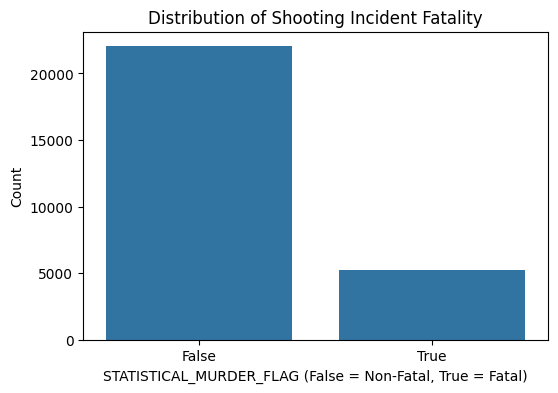

In [ ]:
target_counts = df['STATISTICAL_MURDER_FLAG'].value_counts()
target_percentage = df['STATISTICAL_MURDER_FLAG'].value_counts(normalize=True) * 100

taget_distribution_df=pd.DataFrame({
    'target_counts':target_counts,
    'target_percentage':target_percentage
})
print("Target Distribution Summary:")
display(taget_distribution_df)

plt.figure(figsize=(6,4))
sns.countplot(x='STATISTICAL_MURDER_FLAG', data=df)
plt.title("Distribution of Shooting Incident Fatality")
plt.xlabel("STATISTICAL_MURDER_FLAG (False = Non-Fatal, True = Fatal)")
plt.ylabel("Count")
plt.show()


**Insights**
- The dataset shows a clear class imbalance, with approximately 80.7% non-fatal incidents and 19.3% fatal incidents.

- Fatal incidents constitute a minority class, indicating an imbalanced classification problem.

- The imbalance may bias certain machine learning algorithms toward predicting the majority (non-fatal) class.

- Model evaluation should not rely solely on accuracy; metrics such as Precision, Recall, F1-score, and ROC-AUC will be more appropriate.

- Class imbalance handling techniques (e.g., class weights, SMOTE, or balanced sampling) may be required during modeling.

**next Step:**

Proceed with missing value analysis to assess data completeness and determine appropriate imputation or feature removal strategies.

#Missing Value Assessment

A missing value analysis was performed to quantify the extent of incomplete data across all features.

- The total count of missing values was calculated for each column.

- The percentage of missing values was computed relative to the total number of records.

- Features were sorted in descending order of missing percentage to prioritize data cleaning decisions.

This analysis helps identify:

- Columns with significant data gaps

- Features requiring imputation

- Features that may need to be dropped due to excessive missingness

In [ ]:
missing_values_count=df.isnull().sum()
missing_values_percentage=(missing_values_count/len(df))*100

missing_values_df=pd.DataFrame({
    'missing_values_count':missing_values_count,
    'missing_values_percentage':missing_values_percentage
})

missing_values_df = missing_values_df.sort_values(by="missing_values_percentage", ascending=False)
print("Missing Value Summary:")
display(missing_values_df)

Missing Value Summary:


,missing_values_count,missing_values_percentage
LOC_OF_OCCUR_DESC,25596,93.717047
LOC_CLASSFCTN_DESC,25596,93.717047
LOCATION_DESC,14977,54.836702
PERP_AGE_GROUP,9344,34.212068
PERP_SEX,9310,34.087581
PERP_RACE,9310,34.087581
Latitude,10,0.036614
Lon_Lat,10,0.036614
Longitude,10,0.036614
JURISDICTION_CODE,2,0.007323


#Missing Value Distribution

Visualized the percentage of missing values across features to identify data quality issues.

This analysis helps in:

- Detecting high-missing columns

- Prioritizing feature removal or imputation strategies

- Supporting informed preprocessing decisions

Features with significant missing percentages will be evaluated for potential removal or appropriate treatment in the data cleaning phase.

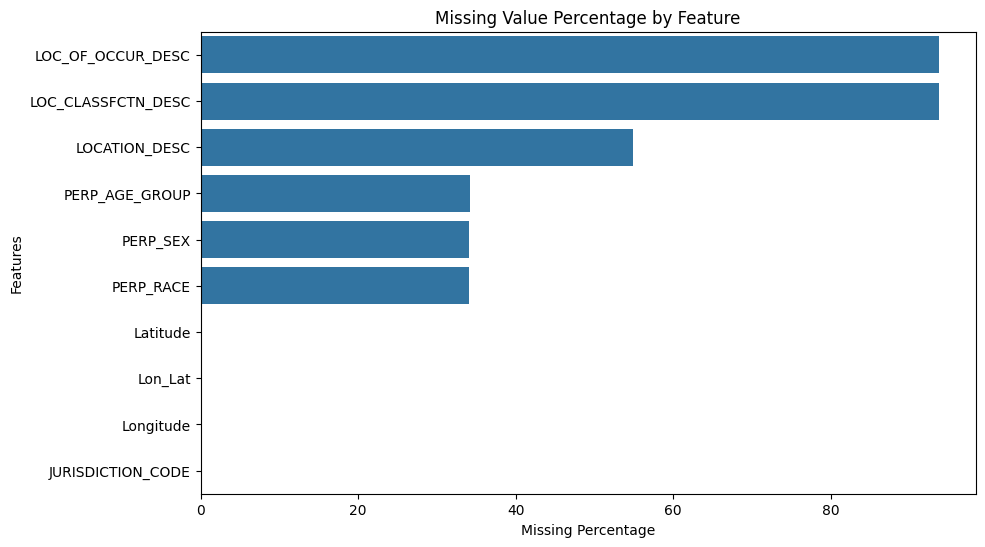

In [ ]:
missing_plot = missing_values_df[missing_values_df["missing_values_count"] > 0]

plt.figure(figsize=(10,6))
sns.barplot(
    x=missing_plot["missing_values_percentage"],
    y=missing_plot.index
)

plt.title("Missing Value Percentage by Feature")
plt.xlabel("Missing Percentage")
plt.ylabel("Features")
plt.show()

**Insights from Missing Value Analysys**

- `LOC_OF_OCCUR_DESC` and `LOC_CLASSFCTN_DESC` contain extremely high missing values (>93%), making them unreliable for meaningful analysis and strong candidates for removal.

- `LOCATION_DESC` has more than 50% missing data, significantly reducing its predictive strength and increasing noise risk.

- Perpetrator-related features (`PERP_AGE_GROUP`, `PERP_SEX`, `PERP_RACE`) have moderate missing values (~34%), indicating incomplete suspect information that may require categorical imputation or separate handling.

- Geospatial columns (`Latitude`, `Longitude`, `Lon_Lat`) have negligible missing values (<0.05%), suggesting high spatial data completeness.

- Core structural and target-related fields (`OCCUR_DATE`, `BORO, PRECINCT`, `STATISTICAL_MURDER_FLAG`, `victim attributes`) contain no missing values, indicating strong dataset stability for modeling.

- `JURISDICTION_CODE` has only 2 missing values (<0.01%), which can be handled via simple imputation without affecting distribution.

**Analytical Interpretation**

- The dataset exhibits selective missingness concentrated primarily in descriptive and perpetrator-related fields, while core structural, temporal, spatial, and target variables remain largely complete.

- This pattern suggests that incident-level data is reliable, but suspect-level metadata may require careful preprocessing to avoid bias introduction.

**Next Step**

- Validate whether high-missing columns also have low information density using Unique Value Analysis.

- Make informed decisions on column removal or imputation strategies based on uniqueness and predictive relevance.

#Unique Value Analysis

Calculated the number and percentage of unique values for each feature to assess cardinality and identify potential high-variance or identifier-like columns.

This step helps in:

- Detecting ID columns or near-unique features

- Identifying high-cardinality categorical variables

- Supporting feature selection and preprocessing decisions

Features with extremely high uniqueness may not contribute meaningful predictive value and may require removal or transformation.

In [ ]:
unique_values_count = df.nunique()
unique_values_percentage = (unique_values_count / len(df)) * 100

unique_values_df = pd.DataFrame({
    'unique_values_count': unique_values_count,
    'unique_values_percentage': unique_values_percentage
})
unique_values_df = unique_values_df.sort_values(
    by="unique_values_percentage",
    ascending=False
)
print("Unique Value Summary:")
display(unique_values_df)


Unique Value Summary:


,unique_values_count,unique_values_percentage
INCIDENT_KEY,21420,78.427065
Lon_Lat,12645,46.298330
Latitude,12619,46.203134
Longitude,12607,46.159197
Y_COORD_CD,12283,44.972906
X_COORD_CD,12088,44.258934
OCCUR_DATE,5761,21.093292
OCCUR_TIME,1421,5.202841
PRECINCT,77,0.281927
LOCATION_DESC,40,0.146456


#Unique Value Percentage Analysis

This visualization illustrates the percentage of unique values for each feature in the dataset.

- The objective of this analysis is to:

- Identify high-cardinality features

- Detect potential identifier columns

- Support feature selection decisions

Features with very high uniqueness may represent identifiers, while features with low uniqueness typically indicate categorical variables.

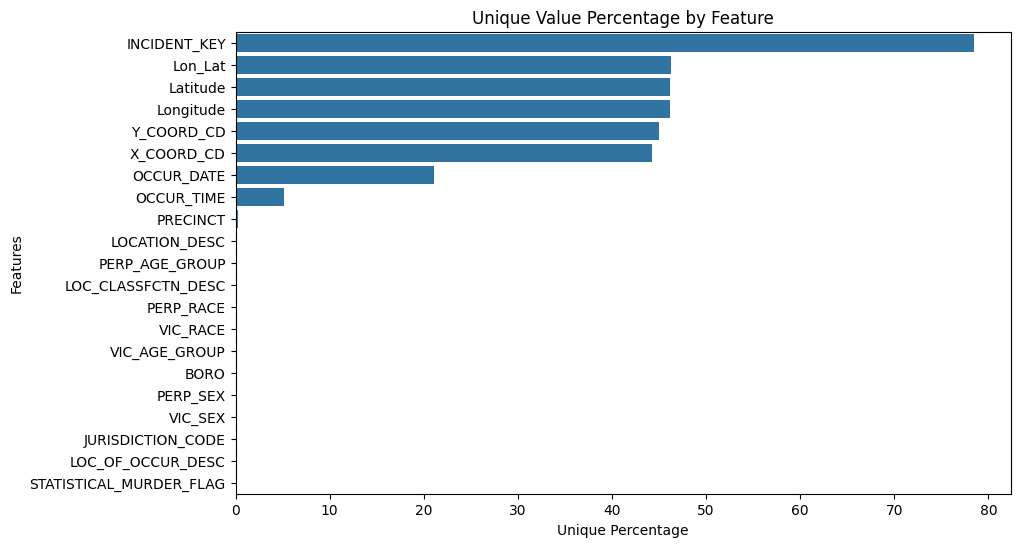

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(
    x=unique_values_df["unique_values_percentage"],
    y=unique_values_df.index
)
plt.title("Unique Value Percentage by Feature")
plt.xlabel("Unique Percentage")
plt.ylabel("Features")
plt.show()


**Insights from Uinque Value Analysys**

- INCIDENT_KEY has 78% unique values, confirming it behaves as an identifier column and holds no predictive analytical value.

- Geospatial fields (Latitude, Longitude, Lon_Lat, X_COORD_CD, Y_COORD_CD) show high uniqueness (~44–46%), indicating near-continuous spatial representation and potential redundancy among these features.

- OCCUR_DATE has ~21% uniqueness, suggesting a wide temporal spread of incidents across multiple years.

- OCCUR_TIME has ~5% uniqueness, reflecting clustering of incidents within specific time intervals rather than uniform distribution.

- PRECINCT contains 77 unique values, representing distinct policing zones and likely holding strong location-based predictive relevance.

- LOCATION_DESC has only 40 unique values despite high missing rates (>50%), indicating limited granularity and reduced analytical strength.

- Perpetrator and victim demographic features show low uniqueness (3–10 categories), making them suitable for categorical modeling.

- STATISTICAL_MURDER_FLAG correctly contains only 2 unique values, validating proper binary encoding.

**Analytical Interpretation:**

- Identifier columns (INCIDENT_KEY) should be removed before modeling.

- Spatial coordinates require correlation validation to avoid multicollinearity.

- Low-cardinality categorical features are well-suited for encoding.

- High-missing, low-unique descriptive columns likely add noise rather than predictive value.

**Next Step:**

- Drop identifier column (INCIDENT_KEY).

- Validate spatial feature redundancy using correlation analysis.

- Finalize removal of high-missing, low-information columns.

- Proceed with feature engineering and structured EDA.

#Categorical Data Type Standardization

Relevant categorical features were explicitly converted to the `category` data type to ensure correct interpretation during analysis and modeling.

This includes:

- Administrative identifiers (`JURISDICTION_CODE`, `BORO`, `PRECINCT`)

- Demographic attributes of perpetrator and victim (`PERP_*`, `VIC_*`)

Converting these variables improves memory efficiency and ensures they are treated as categorical rather than numerical features in downstream analysis.

In [ ]:
# Convert Jurisdiction Code to Category
df['JURISDICTION_CODE'] = df['JURISDICTION_CODE'].astype('category')
# Convert region columns to category
df['BORO'] = df['BORO'].astype('category')
df['PRECINCT'] = df['PRECINCT'].astype('category')

# Convert perpetrator & victim columns to category
cat_cols = [
    'PERP_AGE_GROUP', 'PERP_SEX', 'PERP_RACE',
    'VIC_AGE_GROUP', 'VIC_SEX', 'VIC_RACE'
]

for col in cat_cols:
    df[col] = df[col].astype('category')

**Duplicate Row Detection**

The dataset is evaluated for duplicate records using df.duplicated() to ensure data integrity.

Duplicate rows can artificially inflate incident counts, distort fatality rates, and negatively impact model performance. Identifying and handling duplicates at this stage ensures that subsequent analysis and modeling are based on unique observations only.

In [ ]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


#Duplicate Column Assessment

This step evaluates whether any columns in the dataset contain identical values, indicating redundant or duplicated features.

A pairwise comparison is performed across all columns to detect exact duplicates.

**Objective**

- Identify redundant features

- Prevent multicollinearity issues

- Reduce unnecessary memory usage

- Ensure a clean and non-redundant feature set before feature engineering and modeling

If duplicate columns are detected, one of the redundant columns will be removed to maintain dataset integrity.

In [ ]:
# Duplicate Column Check
duplicate_cols = []

for i in range(len(df.columns)):
    for j in range(i + 1, len(df.columns)):
        if df.iloc[:, i].equals(df.iloc[:, j]):
            duplicate_cols.append((df.columns[i], df.columns[j]))

print("Duplicate Columns:", duplicate_cols)

Duplicate Columns: []


#Removal of Redundant and High-Missing Columns

The following columns were removed from the dataset:

- LOC_OF_OCCUR_DESC

- LOC_CLASSFCTN_DESC

- Lon_Lat

These features were dropped due to either excessive missing values or redundancy with existing location-based variables. Removing such columns helps reduce noise and improve analytical clarity before proceeding with further exploration and modeling.

In [ ]:
df = df.drop(columns=[
    'LOC_OF_OCCUR_DESC',
    'LOC_CLASSFCTN_DESC',
    'Lon_Lat'
])

**Column Removal Decision Insights**-

The following columns were removed:

- LOC_OF_OCCUR_DESC

- LOC_CLASSFCTN_DESC

-Lon_Lat

**Analytical Justification:**

- LOC_OF_OCCUR_DESC and LOC_CLASSFCTN_DESC had extremely high missing values (>93%), significantly reducing their analytical reliability.

- Lon_Lat represents redundant spatial information already captured by Latitude and Longitude, increasing multicollinearity risk.

- Removing these columns improves dataset clarity and reduces noise without compromising predictive information.

#Temporal Feature Engineering

Additional time-based features were derived from `OCCUR_DATE` and `OCCUR_TIME` to support trend and pattern analysis.

The following features were created:

- `YEAR` – Year of incident

- `MONTH` – Numeric month (1–12)

- `MONTH_NAME` – Month label for visualization

- `DAY_OF_WEEK` – Numeric weekday (0–6)

- `DAY_NAME` – Weekday label

- `HOUR` – Hour of occurrence (0–23)

These derived features enable temporal trend analysis and help identify seasonal, weekly, and hourly patterns in shooting incidents.

In [ ]:
# YEAR
df['YEAR'] = df['OCCUR_DATE'].dt.year

# MONTH (numeric)
df['MONTH'] = df['OCCUR_DATE'].dt.month

# MONTH NAME (for better EDA visualization)
df['MONTH_NAME'] = df['OCCUR_DATE'].dt.month_name()

# DAY OF WEEK (numeric 0-6)
df['DAY_OF_WEEK'] = df['OCCUR_DATE'].dt.dayofweek

# DAY NAME (for better interpretation)
df['DAY_NAME'] = df['OCCUR_DATE'].dt.day_name()

# HOUR
df['HOUR'] = df['OCCUR_TIME'].dt.hour

#Numerical Feature Analysis

The primary numerical features related to geographic coordinates are analyzed to understand their distribution and variability.

- Summary statistics (`describe()`) are used to examine central tendency and spread.

- Histograms are plotted to assess distribution shape and identify potential skewness or outliers.

This step helps evaluate the spatial characteristics of incidents before proceeding to deeper analytical modeling.

Numerical Columns: ['Latitude', 'Longitude', 'X_COORD_CD', 'Y_COORD_CD']


,Latitude,Longitude,X_COORD_CD,Y_COORD_CD
count,27302.000000,27302.000000,2.731200e+04,27312.000000
mean,40.737892,-73.909051,1.009449e+06,208127.401608
std,0.087525,0.066272,1.837783e+04,31886.377757
min,40.511586,-74.249303,9.149281e+05,125756.718750
25%,40.668481,-73.943027,1.000029e+06,182834.335938
50%,40.700318,-73.915221,1.007731e+06,194486.570312
75%,40.824067,-73.882330,1.016838e+06,239518.468750
max,40.910818,-73.702046,1.066815e+06,271127.687500


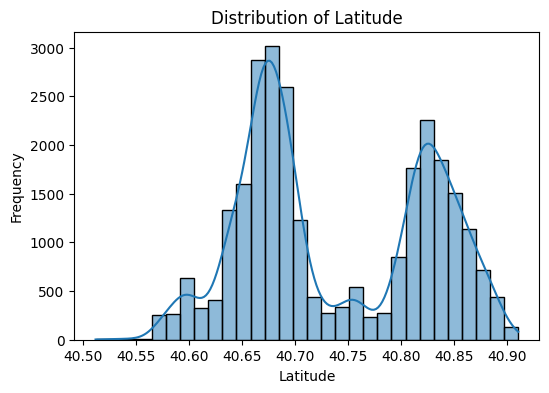

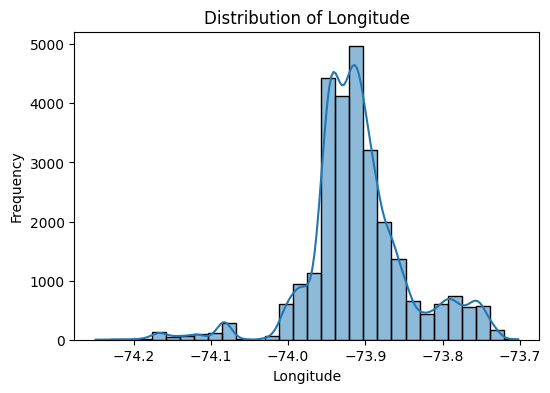

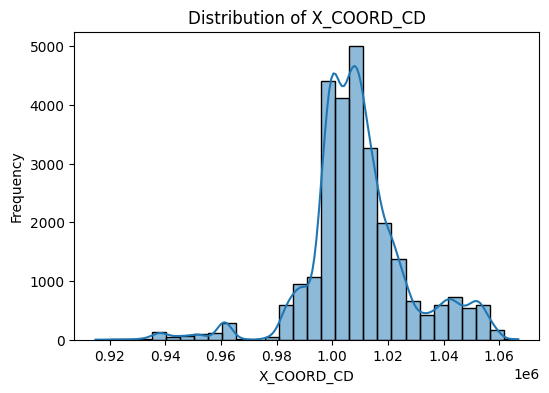

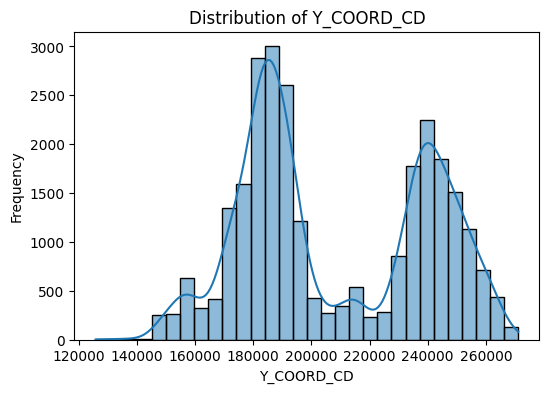

In [ ]:
num_cols = ['Latitude','Longitude','X_COORD_CD','Y_COORD_CD']
print("Numerical Columns:", list(num_cols))

# Summary statistics
display(df[num_cols].describe())

# Distribution plots
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

#Time-Based Distribution Analysis (YEAR & HOUR)

The distribution of shooting incidents is analyzed across `YEAR` and `HOUR` to understand temporal patterns in occurrence frequency.

- `YEAR` helps identify long-term trends in incident volume.

- `HOUR` helps detect time-of-day concentration patterns.

This analysis supports identification of temporal risk patterns and potential peak periods of incident occurrence.

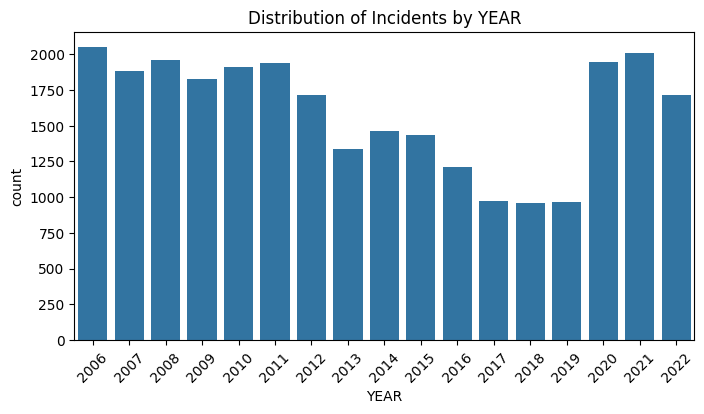

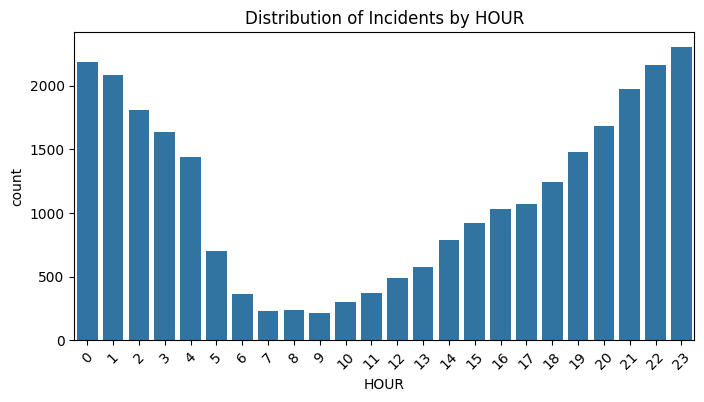

In [ ]:
numeric_time_features = ['YEAR', 'HOUR']

for col in numeric_time_features:
    plt.figure(figsize=(8,4))
    sns.countplot(x=col, data=df, order=sorted(df[col].dropna().unique()))
    plt.title(f"Distribution of Incidents by {col}")
    plt.xticks(rotation=45)
    plt.show()



## Outlier Detection – Numerical Features

Boxplots and the IQR method are used to identify extreme values in numerical features. This helps assess data distribution and determine whether outlier treatment is required prior to modeling.


===== INCIDENT_KEY =====


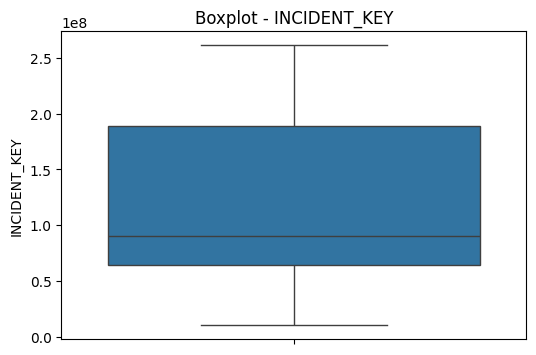

Outliers detected in INCIDENT_KEY: 0

===== X_COORD_CD =====


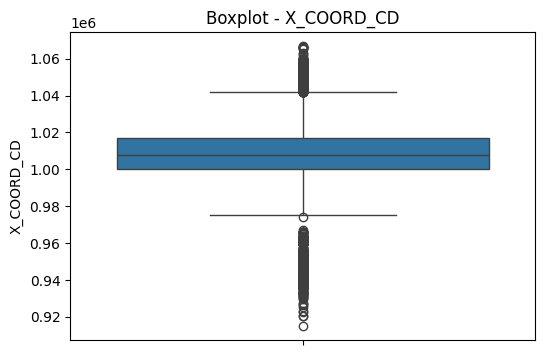

Outliers detected in X_COORD_CD: 2697

===== Y_COORD_CD =====


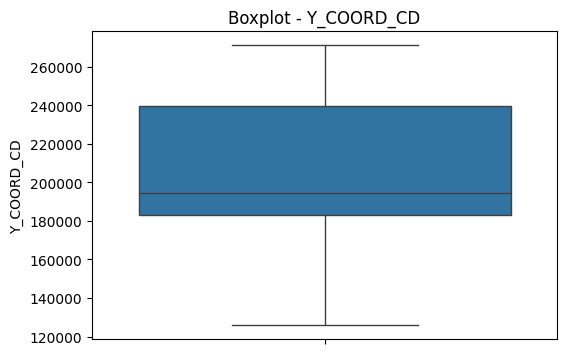

Outliers detected in Y_COORD_CD: 0

===== Latitude =====


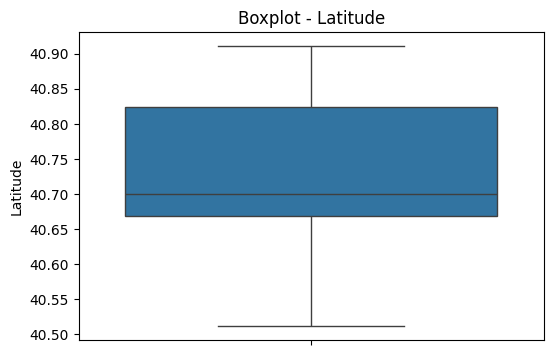

Outliers detected in Latitude: 0

===== Longitude =====


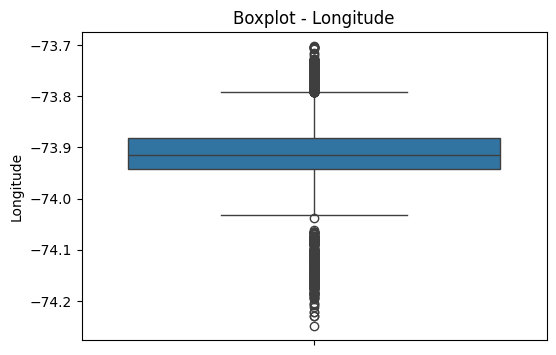

Outliers detected in Longitude: 2683


In [ ]:
# Outlier Detection - Numerical Features
num_cols = df.select_dtypes(include=['int64','float64']).columns
num_cols = [col for col in num_cols if col != 'STATISTICAL_MURDER_FLAG']

for col in num_cols:

    print(f"\n===== {col} =====")

    # Boxplot
    plt.figure(figsize=(6,4))
    sns.boxplot(y=df[col])
    plt.title(f"Boxplot - {col}")
    plt.show()

    # IQR Calculation
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"Outliers detected in {col}: {len(outliers)}")

#Statistical Summary – Numerical Features

A statistical summary of numerical features is generated using df.describe() to understand their central tendency and distribution characteristics.

This provides key metrics such as mean, standard deviation, minimum, maximum, and quartile values.

The summary helps identify:

- Feature range and scale

- Potential outliers

- Skewness patterns

- Data spread before modeling

In [ ]:
# Statistical Summary - Numerical
display(df.describe())

,INCIDENT_KEY,OCCUR_DATE,OCCUR_TIME,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,YEAR,MONTH,DAY_OF_WEEK,HOUR
count,2.731200e+04,27312,27312,2.731200e+04,27312.000000,27302.000000,27302.000000,27312.000000,27312.000000,27312.000000,27312.000000
mean,1.208605e+08,2014-01-06 23:14:14.130052608,1900-01-01 12:41:31.709138944,1.009449e+06,208127.401608,40.737892,-73.909051,2013.492494,6.825168,3.342560,12.222832
min,9.953245e+06,2006-01-01 00:00:00,1900-01-01 00:00:00,9.149281e+05,125756.718750,40.511586,-74.249303,2006.000000,1.000000,0.000000,0.000000
25%,6.386088e+07,2009-07-18 00:00:00,1900-01-01 03:27:00,1.000029e+06,182834.335938,40.668481,-73.943027,2009.000000,5.000000,1.000000,3.000000
50%,9.037222e+07,2013-04-29 00:00:00,1900-01-01 15:11:00,1.007731e+06,194486.570312,40.700318,-73.915221,2013.000000,7.000000,4.000000,15.000000
75%,1.888102e+08,2018-10-15 00:00:00,1900-01-01 20:45:00,1.016838e+06,239518.468750,40.824067,-73.882330,2018.000000,9.000000,5.000000,20.000000
max,2.611902e+08,2022-12-31 00:00:00,1900-01-01 23:59:00,1.066815e+06,271127.687500,40.910818,-73.702046,2022.000000,12.000000,6.000000,23.000000
std,7.341286e+07,NaN,NaN,1.837783e+04,31886.377757,0.087525,0.066272,5.143086,3.128859,2.103358,8.486079


#Correlation Analysis – Numerical Features

A correlation matrix is generated to examine linear relationships among numerical features.

This analysis helps to:

- Identify highly correlated variables

- Detect potential multicollinearity

- Understand feature relationships prior to modeling

Strong correlations (positive or negative) may indicate redundant features that require further evaluation during preprocessing.

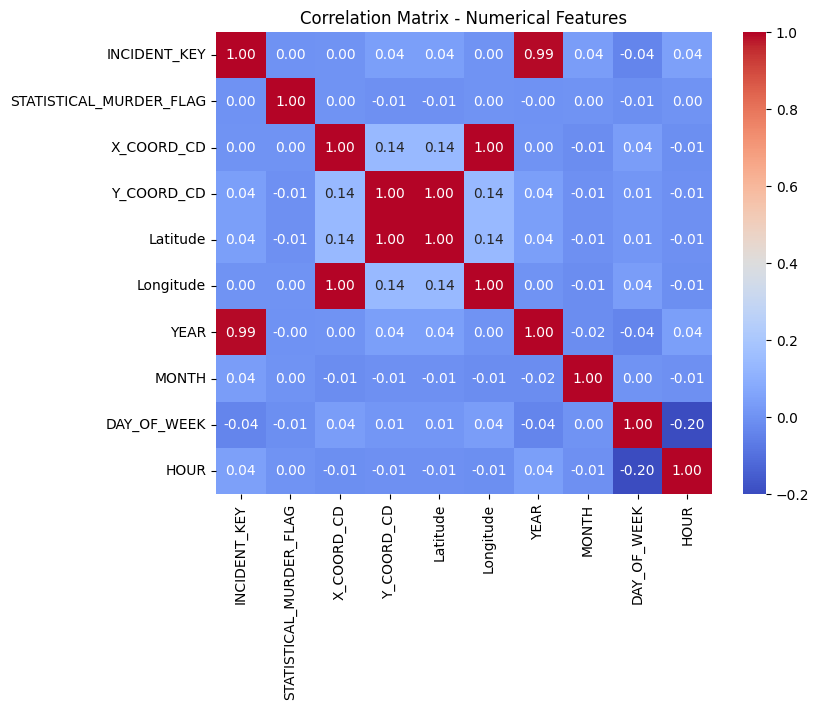

In [ ]:
# Correlation Matrix (Numerical)
plt.figure(figsize=(8,6))
corr_matrix = df.corr(numeric_only=True)

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Matrix - Numerical Features")
plt.show()

In [ ]:
# High Correlation Check
corr_matrix = df.corr(numeric_only=True)

high_corr = []

for col in corr_matrix.columns:
    for row in corr_matrix.index:
        if col != row and abs(corr_matrix.loc[row, col]) > 0.95:
            high_corr.append((row, col, corr_matrix.loc[row, col]))

print("Highly Correlated Pairs (>0.95):")
print(high_corr)

Highly Correlated Pairs (>0.95):
[('YEAR', 'INCIDENT_KEY', np.float64(0.9923766767238873)), ('Longitude', 'X_COORD_CD', np.float64(0.9999975949891944)), ('Latitude', 'Y_COORD_CD', np.float64(0.9999997325251296)), ('Y_COORD_CD', 'Latitude', np.float64(0.9999997325251296)), ('X_COORD_CD', 'Longitude', np.float64(0.9999975949891944)), ('INCIDENT_KEY', 'YEAR', np.float64(0.9923766767238873))]


#**Insights from Univariate numerical value Analysys**

**1️⃣ Geospatial Distribution (Latitude & Longitude)**

- Latitude distribution shows two clear density clusters, indicating concentration of incidents in specific geographic zones rather than uniform spread.

- Longitude also shows strong central clustering with minor tails, suggesting incidents are spatially concentrated in particular borough regions.

- The bimodal nature of Latitude & Y_COORD_CD suggests spatial segmentation of crime-prone areas.

** 2️⃣ Coordinate Redundancy Insight**

Correlation results show:

- Longitude ↔ X_COORD_CD → ~0.99999

- Latitude ↔ Y_COORD_CD → ~0.99999

This confirms perfect **spatial duplication**.

👉 Keeping both coordinate systems will introduce multicollinearity.

👉 Only one representation should be retained (prefer Latitude & Longitude for interpretability).

**3️⃣ Time-Based Univariate (YEAR)**

- Incident volume declines from 2012–2018.

- Significant rise observed in 2020–2021.

- No extreme single-year spike observed.

This suggests cyclical or policy-driven fluctuations rather than isolated anomalies.

**4️⃣ Hourly Distribution Insight**

- Incidents peak during late-night hours (21–23).

- Early morning hours (5–8 AM) show lowest activity.

This indicates strong temporal clustering and supports time-based risk profiling.

**5️⃣ Outlier Analysis**

- X_COORD_CD and Longitude show significant statistical outliers.

- Latitude and Y_COORD_CD show stable distributions with minimal extreme deviation.

However, since these are real-world coordinates, extreme values likely represent valid boundary locations rather than errors.

👉 Aggressive outlier removal is not recommended.

**6️⃣ Correlation Insights**

- INCIDENT_KEY ↔ YEAR correlation = 0.99

- This indicates the identifier is sequential and time-linked.

👉 INCIDENT_KEY must be dropped before modeling.

- Target variable shows near-zero linear correlation with numerical features.

This suggests fatality is influenced more by categorical or contextual factors rather than pure numeric magnitude.

**Strategic Decisions From These Results**

- 1️⃣ Drop INCIDENT_KEY (identifier).
- 2️⃣ Drop either (X_COORD_CD, Y_COORD_CD) or (Latitude, Longitude).
- 3️⃣ Retain time features — they show meaningful structure.
- 4️⃣ Do not remove coordinate outliers aggressively.

#Categorical Feature Distribution Analysis

Categorical variables (excluding time-based name features) are analyzed to understand their distribution and class balance.

For each categorical feature:

- Frequency (Count) and percentage distribution are computed

- A count plot is generated to visualize category dominance and imbalance

This step helps identify skewed categories, dominant groups, and potential class imbalance before proceeding to bivariate analysis and modeling.

Categorical Columns:
['BORO', 'PRECINCT', 'JURISDICTION_CODE', 'LOCATION_DESC', 'PERP_AGE_GROUP', 'PERP_SEX', 'PERP_RACE', 'VIC_AGE_GROUP', 'VIC_SEX', 'VIC_RACE']

===== BORO =====


,Count,Percentage
BORO,,
BROOKLYN,10933,40.03
BRONX,7937,29.06
QUEENS,4094,14.99
MANHATTAN,3572,13.08
STATEN ISLAND,776,2.84


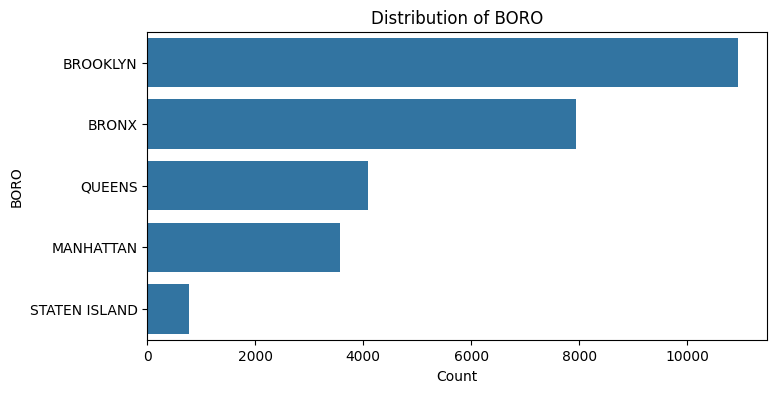


===== PRECINCT =====


,Count,Percentage
PRECINCT,,
75,1557,5.70
73,1452,5.32
67,1216,4.45
44,1020,3.73
79,1012,3.71
...,...,...
112,23,0.08
19,20,0.07
111,11,0.04


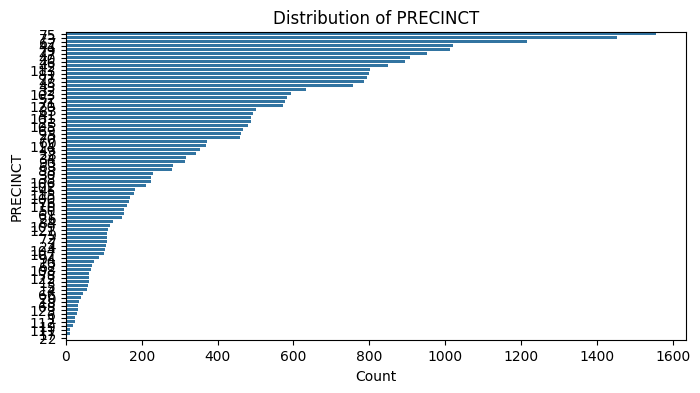


===== JURISDICTION_CODE =====


,Count,Percentage
JURISDICTION_CODE,,
0.0,22809,83.52
2.0,4427,16.21
1.0,74,0.27


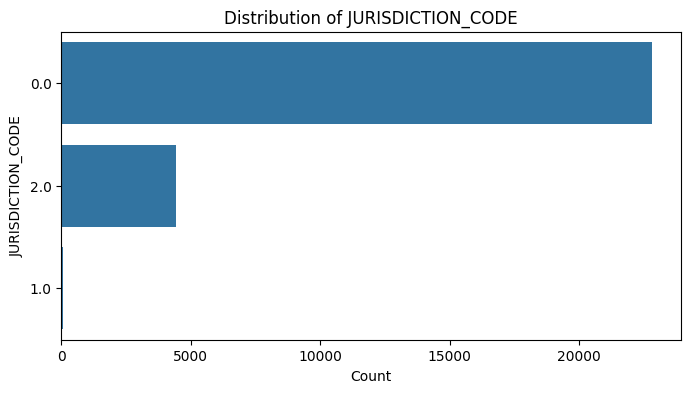


===== LOCATION_DESC =====


,Count,Percentage
LOCATION_DESC,,
MULTI DWELL - PUBLIC HOUS,4832,39.17
MULTI DWELL - APT BUILD,2835,22.98
(null),977,7.92
PVT HOUSE,951,7.71
GROCERY/BODEGA,694,5.63
BAR/NIGHT CLUB,628,5.09
COMMERCIAL BLDG,292,2.37
RESTAURANT/DINER,204,1.65
NONE,175,1.42


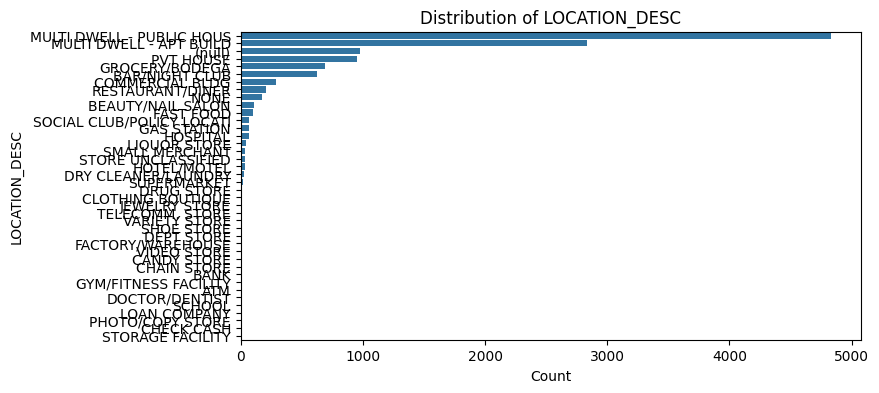


===== PERP_AGE_GROUP =====


,Count,Percentage
PERP_AGE_GROUP,,
18-24,6222,34.63
25-44,5687,31.65
UNKNOWN,3148,17.52
<18,1591,8.85
(null),640,3.56
45-64,617,3.43
65+,60,0.33
1020,1,0.01
224,1,0.01


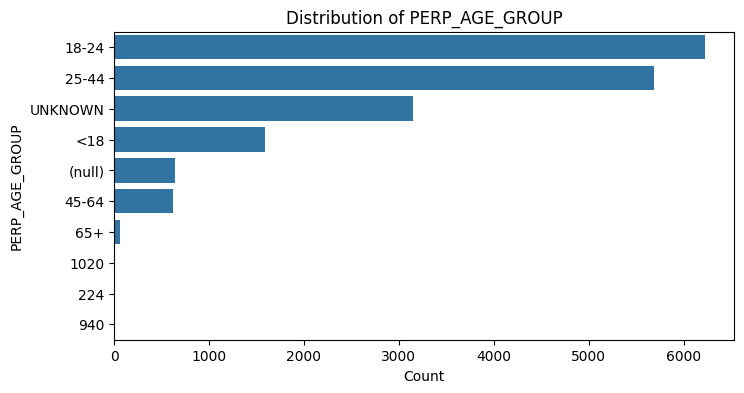


===== PERP_SEX =====


,Count,Percentage
PERP_SEX,,
M,15439,85.76
U,1499,8.33
(null),640,3.56
F,424,2.36


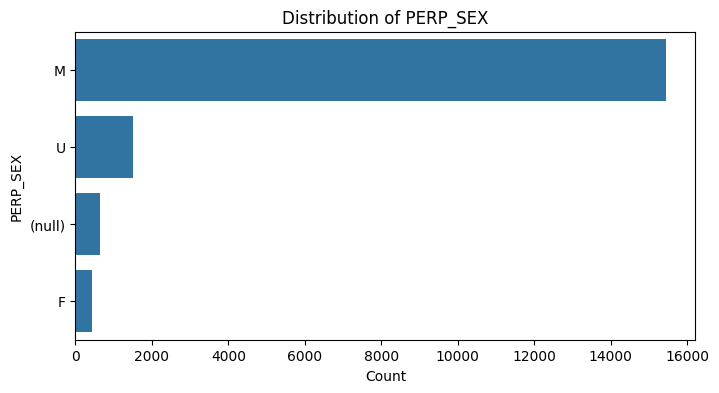


===== PERP_RACE =====


,Count,Percentage
PERP_RACE,,
BLACK,11432,63.50
WHITE HISPANIC,2341,13.00
UNKNOWN,1836,10.20
BLACK HISPANIC,1314,7.30
(null),640,3.56
WHITE,283,1.57
ASIAN / PACIFIC ISLANDER,154,0.86
AMERICAN INDIAN/ALASKAN NATIVE,2,0.01


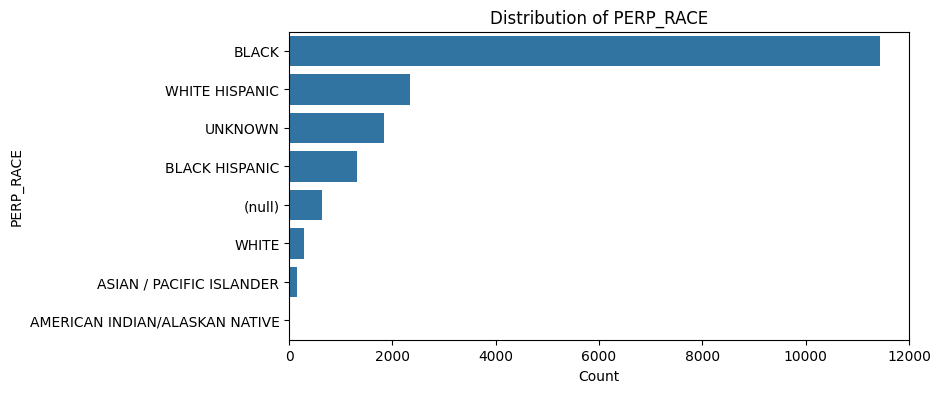


===== VIC_AGE_GROUP =====


,Count,Percentage
VIC_AGE_GROUP,,
25-44,12281,44.97
18-24,10086,36.93
<18,2839,10.39
45-64,1863,6.82
65+,181,0.66
UNKNOWN,61,0.22
1022,1,0.00


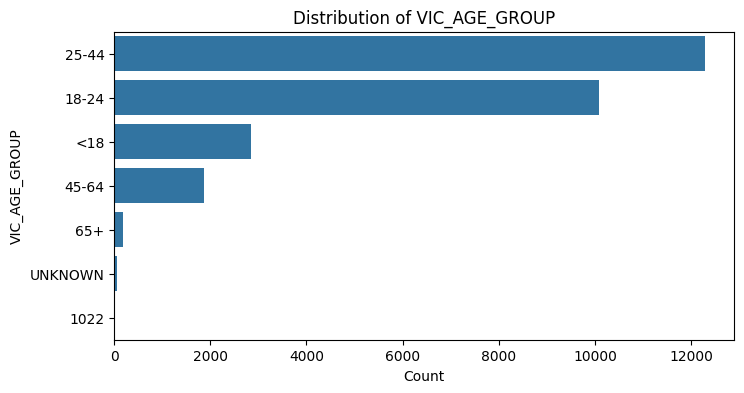


===== VIC_SEX =====


,Count,Percentage
VIC_SEX,,
M,24686,90.39
F,2615,9.57
U,11,0.04


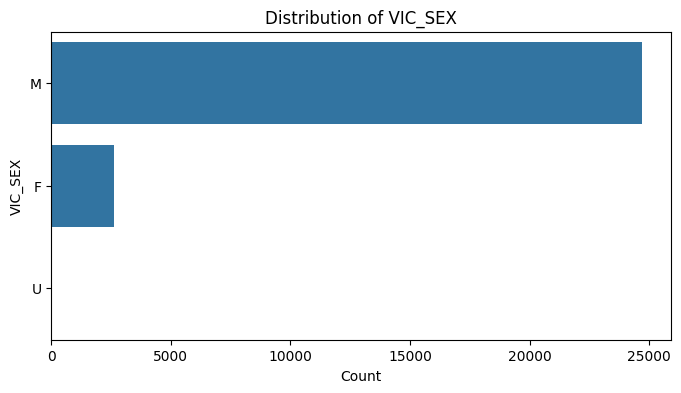


===== VIC_RACE =====


,Count,Percentage
VIC_RACE,,
BLACK,19439,71.17
WHITE HISPANIC,4049,14.82
BLACK HISPANIC,2646,9.69
WHITE,698,2.56
ASIAN / PACIFIC ISLANDER,404,1.48
UNKNOWN,66,0.24
AMERICAN INDIAN/ALASKAN NATIVE,10,0.04


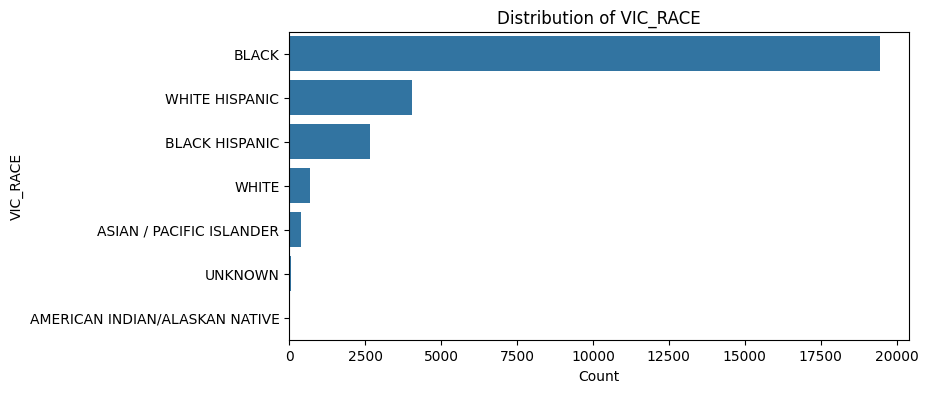

In [ ]:
# Categorical Analysis (Except Time Name Columns)

cat_cols = df.select_dtypes(include=['object','category']).columns

# Remove MONTH_NAME & DAY_NAME from this list
cat_cols = [col for col in cat_cols if col not in ['MONTH_NAME', 'DAY_NAME']]

print("Categorical Columns:")
print(list(cat_cols))

for col in cat_cols:

    print(f"\n===== {col} =====")

    # Count & Percentage
    counts = df[col].value_counts()
    percentage = df[col].value_counts(normalize=True) * 100

    summary_df = pd.DataFrame({
        'Count': counts,
        'Percentage': percentage.round(2)
    })

    display(summary_df)

    # Plot
    plt.figure(figsize=(8,4))
    sns.countplot(y=col, data=df, order=counts.index)

    plt.title(f"Distribution of {col}")
    plt.xlabel("Count")
    plt.ylabel(col)
    plt.show()

#Categorical Analysis – Time-Based Features

Univariate analysis is performed for `MONTH_NAME` and `DAY_NAME` to examine temporal patterns in incident distribution.

The categories are explicitly ordered to maintain chronological sequence (January–December, Monday–Sunday), ensuring meaningful interpretation of trends.

For each feature:

- Absolute counts and percentage distribution are calculated

- A count plot is generated to visualize frequency patterns

This analysis helps identify seasonal and weekday variations in shooting incidents.


===== MONTH_NAME =====


,Count,Percentage
MONTH_NAME,,
January,1716,6.28
February,1340,4.91
March,1688,6.18
April,1983,7.26
May,2571,9.41
June,2829,10.36
July,3238,11.86
August,3156,11.56
September,2572,9.42


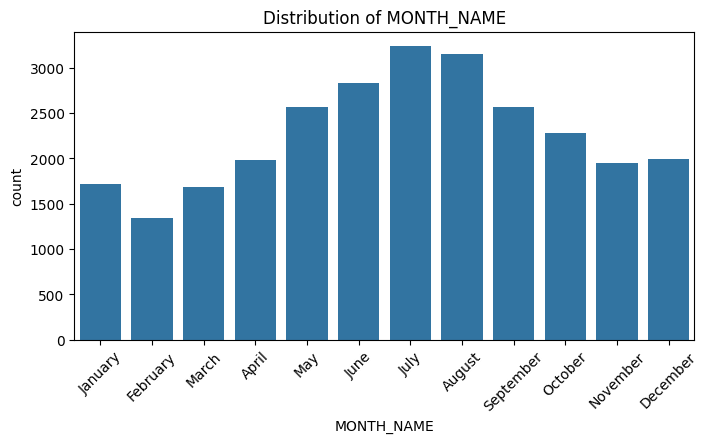


===== DAY_NAME =====


,Count,Percentage
DAY_NAME,,
Monday,3883,14.22
Tuesday,3163,11.58
Wednesday,3000,10.98
Thursday,3034,11.11
Friday,3585,13.13
Saturday,5195,19.02
Sunday,5452,19.96


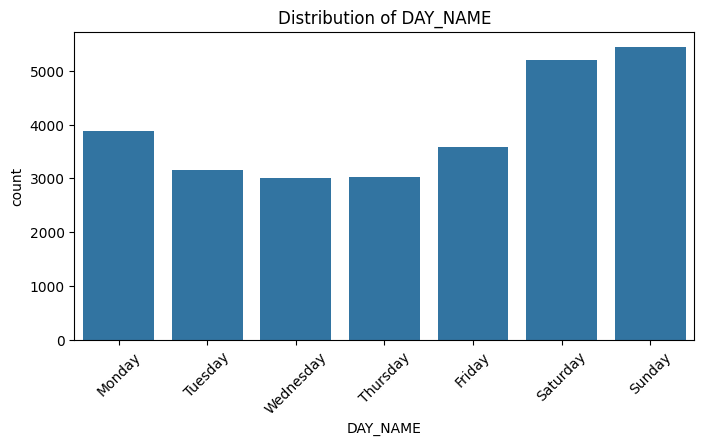

In [ ]:
# Categorical Analysis - Time Name Columns
ordered_categories = {
    'MONTH_NAME': [
        'January','February','March','April','May','June',
        'July','August','September','October','November','December'
    ],
    'DAY_NAME': [
        'Monday','Tuesday','Wednesday','Thursday',
        'Friday','Saturday','Sunday'
    ]
}

for col, order in ordered_categories.items():

    print(f"\n===== {col} =====")

    counts = df[col].value_counts().reindex(order)
    percentage = (counts / len(df)) * 100

    summary_df = pd.DataFrame({
        'Count': counts,
        'Percentage': percentage.round(2)
    })

    display(summary_df)

    plt.figure(figsize=(8,4))
    sns.countplot(x=col, data=df, order=order)

    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.show()

**Insights fro univariate categorical value analaysys**

**1️⃣ BORO Distribution**

- Brooklyn accounts for ~40% of total incidents, making it the highest concentration borough.

- Bronx follows with ~29%, indicating strong clustering in these two boroughs.

- Staten Island contributes less than 3%, showing significantly lower incident density.

**Insight:**

Crime distribution is geographically concentrated rather than evenly distributed across boroughs.

**2️⃣ PRECINCT Distribution**

- Incident distribution across 77 precincts is highly uneven.

- Top precincts (e.g., 75, 73, 67) contribute disproportionately higher incident counts.

Several precincts have extremely low incident frequency.

**Insight:**
Localized hotspots exist at the precinct level, suggesting targeted policing zones.

**3️⃣ JURISDICTION_CODE**

- Over 83% of incidents fall under code 0.

- Code 2 contributes ~16%, while code 1 is negligible.

**Insight:**
The dataset is heavily dominated by a single jurisdiction category, indicating potential class imbalance within this feature.

**4️⃣ LOCATION_DESC**

- “MULTI DWELL – PUBLIC HOUSING” dominates the distribution.

- Residential and street-level locations appear more frequently than commercial spaces.

**Insight:**
- Incidents are primarily occurring in residential or community-based environments.

** 5️⃣ PERP_AGE_GROUP**

- 18–24 and 25–44 together account for ~66% of perpetrators.

- Very low representation above 65 years.

**Insight:**
- Younger adult groups are disproportionately represented among perpetrators.

**6️⃣ PERP_SEX**

- Male perpetrators account for ~86% of cases.

- Female representation is very low (~2%).

**Insight:**
Strong gender skew in perpetrator data.

** 7️⃣ PERP_RACE**

- BLACK category accounts for ~63% of recorded perpetrators.

- WHITE HISPANIC and UNKNOWN follow at much lower percentages.

**Insight:**
Clear demographic concentration observed in perpetrator race distribution.

** 8️⃣ VIC_AGE_GROUP**

- Majority of victims fall within 18–44 age range (~81% combined).

- Elderly victims (>65) are minimal.

**Insight:**
Victim age distribution mirrors working-age population exposure.

**9️⃣ VIC_SEX**

- ~90% of victims are male.

**Insight:**
Strong gender dominance among victims similar to perpetrator distribution.

**🔟 VIC_RACE**

- BLACK victims account for ~71% of incidents.

- WHITE HISPANIC follows at ~14%.

**Insight:**
Victim demographic distribution aligns with perpetrator demographic concentration.

** 1️⃣1️⃣ MONTH_NAME**

- Incidents increase from spring and peak during summer (June–August).

- July and August show highest counts.

**Insight:**
Clear seasonal effect with higher activity in warmer months.

** 1️⃣2️⃣ DAY_NAME**

- Weekend days (Saturday & Sunday) account for nearly 39% of incidents combined.

- Weekdays show relatively balanced but lower distribution.

**Insight:**
Strong weekend concentration, supporting temporal risk clustering.

**Strategic Summary:**

- Geographic clustering (BORO & PRECINCT)

- Strong demographic skew (Age, Sex, Race)

- Seasonal & weekend concentration

- Jurisdiction imbalance

These patterns indicate that fatality prediction is likely influenced by:

- Location
- Demographics
- Temporal factors

#Numerical Feature Summary by Target

- This step evaluates the relationship between numerical features and the target variable (`STATISTICAL_MURDER_FLAG`).

- For each numerical feature, the mean value is computed separately for fatal and non-fatal incidents.

- This helps identify whether measurable differences exist between the two classes and provides an initial indication of potential predictive relevance.

In [ ]:
# Numerical Feature Summary by Target
num_cols = df.select_dtypes(include=['int64','float64']).columns
num_cols = [col for col in num_cols if col != 'STATISTICAL_MURDER_FLAG']

for col in num_cols:

    print(f"\n===== {col} =====")

    summary = df.groupby('STATISTICAL_MURDER_FLAG')[col].mean().reset_index()
    display(summary)


===== INCIDENT_KEY =====


,STATISTICAL_MURDER_FLAG,INCIDENT_KEY
0,False,1.208349e+08
1,True,1.209679e+08



===== X_COORD_CD =====


,STATISTICAL_MURDER_FLAG,X_COORD_CD
0,False,1.009432e+06
1,True,1.009518e+06



===== Y_COORD_CD =====


,STATISTICAL_MURDER_FLAG,Y_COORD_CD
0,False,208231.334838
1,True,207692.287291



===== Latitude =====


,STATISTICAL_MURDER_FLAG,Latitude
0,False,40.738178
1,True,40.736695



===== Longitude =====


,STATISTICAL_MURDER_FLAG,Longitude
0,False,-73.909110
1,True,-73.908806


#Numerical Features vs Target (Boxplot Analysis)

Boxplots are used to compare the distribution of numerical features across fatal and non-fatal incidents.

This visualization helps to:

- Identify differences in central tendency between groups

- Detect potential outliers

- Observe variation in numerical features with respect to fatality outcome

This step provides insight into whether numerical variables exhibit meaningful separation between fatal and non-fatal cases.

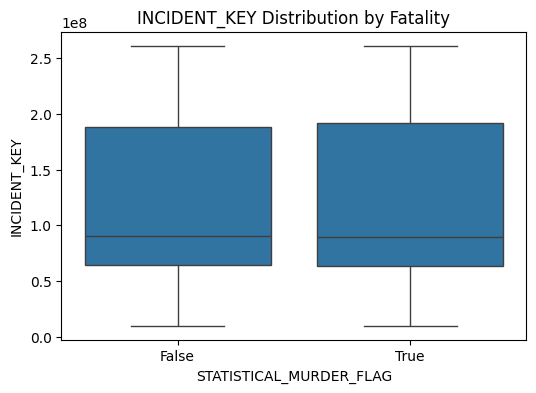

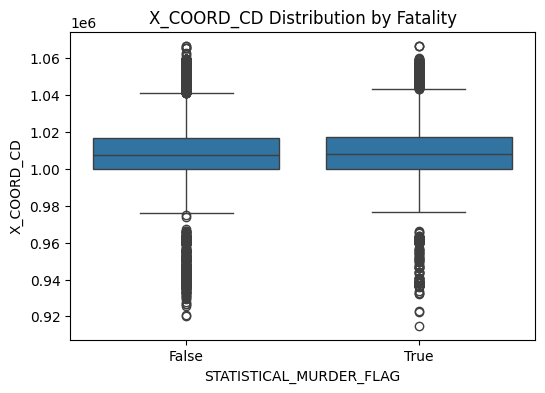

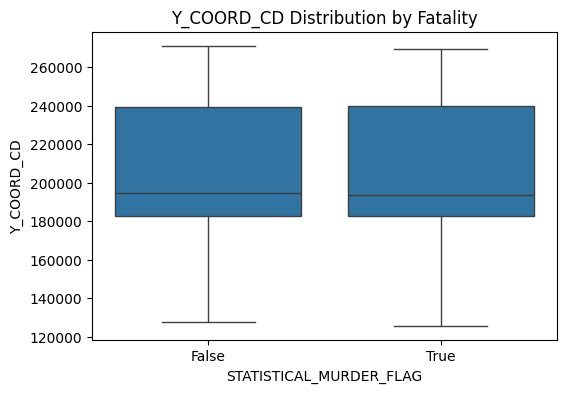

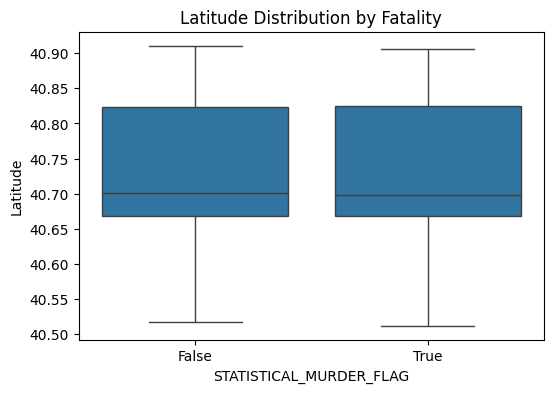

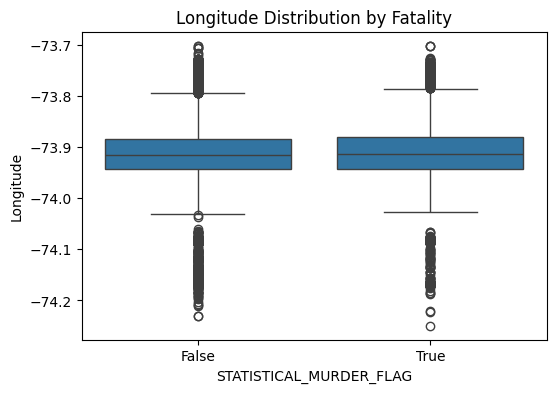

In [ ]:
# Boxplot - Numerical vs Target
for col in num_cols:

    plt.figure(figsize=(6,4))
    sns.boxplot(x='STATISTICAL_MURDER_FLAG', y=col, data=df)

    plt.title(f"{col} Distribution by Fatality")
    plt.show()

#**Insights from bivariate numerical value analysys**

**1️⃣ INCIDENT_KEY vs Fatality**

- Median and distribution of INCIDENT_KEY are nearly identical across fatal and non-fatal cases.

- No visible separation between the two groups.

**Insight:**
INCIDENT_KEY has no predictive relevance and confirms it behaves purely as an identifier.

→ Should be removed before modeling.

**2️⃣ X_COORD_CD vs Fatality**

- Both fatal and non-fatal incidents share almost identical median and IQR ranges.

- Outliers exist in both groups with similar spread.

**Insight:**
No strong spatial separation observed at X-coordinate level between fatal and non-fatal incidents.

** 3️⃣ Y_COORD_CD vs Fatality**

- Overlapping distributions between fatal and non-fatal cases.

- Median values are nearly the same.

**Insight:**
Y-coordinate alone does not differentiate fatal outcomes.

** 4️⃣ Latitude vs Fatality**

- Distributions of latitude for fatal and non-fatal incidents overlap significantly.

- No clear vertical shift or spread difference observed.

**Insight:**
Latitude alone is not a strong discriminator for fatality classification.

5️⃣ Longitude vs Fatality**

- Similar distribution patterns across fatal and non-fatal incidents.

- Outlier structure consistent across both classes.

**Insight:**
Longitude does not independently influence fatality likelihood.

**Overall Numerical Bivariate Conclusion**

- All spatial numerical features show heavy overlap between fatal and non-fatal classes.

- No visible separation in medians or distribution spread.

- Linear correlation with target is near zero (as previously observed).

**Strategic Interpretation:**

- Fatality outcome is unlikely to be driven purely by geographic coordinate magnitude.
- More contextual or categorical features may play a stronger role.

**Next Logical Step**

- Perform fatality rate analysis across categorical features.

- Validate statistical significance using Chi-Square tests.

- Begin feature selection based on predictive contribution rather than numeric magnitude.

#Fatality Rate Summary Function

A reusable function is created to compute fatality metrics for categorical features.

For each category, the function calculates:

- Total incident count

- Fatal incident count

- Fatality rate (%)

The results are sorted in descending order of fatality rate to highlight high-risk categories.

This approach ensures consistent and scalable comparison across multiple features during bivariate analysis.

In [ ]:
# Fatality Summary Function
def fatality_summary(column):

    summary = df.groupby(column)['STATISTICAL_MURDER_FLAG'].agg(
        Total_Count='count',
        Fatal_Count='sum'
    ).reset_index()

    summary['Fatality_Rate_%'] = (
        summary['Fatal_Count'] / summary['Total_Count'] * 100
    )

    summary = summary.sort_values(
        by='Fatality_Rate_%',
        ascending=False
    )

    return summary

#Bivariate Analysis – Fatality Rate by Categorical Features

To evaluate the relationship between categorical features and incident outcomes, the fatality rate (%) is calculated for each category level.

For every categorical feature (excluding time-name features), the following metrics are computed:

- Total number of incidents

- Number of fatal incidents

- Fatality Rate (%)

This approach enables comparison of risk levels across different categories, helping identify groups associated with higher fatality likelihood.

Bar plots are used to visually compare fatality rates across categories for clearer interpretation.

faltality summary table of BORO


,BORO,Total_Count,Fatal_Count,Fatality_Rate_%
4,STATEN ISLAND,776,162,20.876289
3,QUEENS,4094,810,19.785051
0,BRONX,7937,1542,19.427995
1,BROOKLYN,10933,2122,19.409128
2,MANHATTAN,3572,630,17.637178


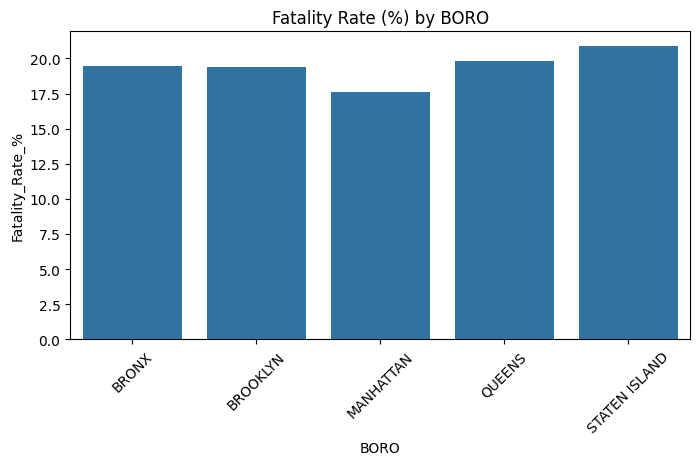

faltality summary table of PRECINCT


,PRECINCT,Total_Count,Fatal_Count,Fatality_Rate_%
75,122,61,25,40.983607
69,112,23,8,34.782609
63,106,224,70,31.250000
1,5,58,17,29.310345
0,1,25,7,28.000000
...,...,...,...,...
16,26,149,18,12.080537
57,100,170,17,10.000000
3,7,109,9,8.256881
12,22,1,0,0.000000


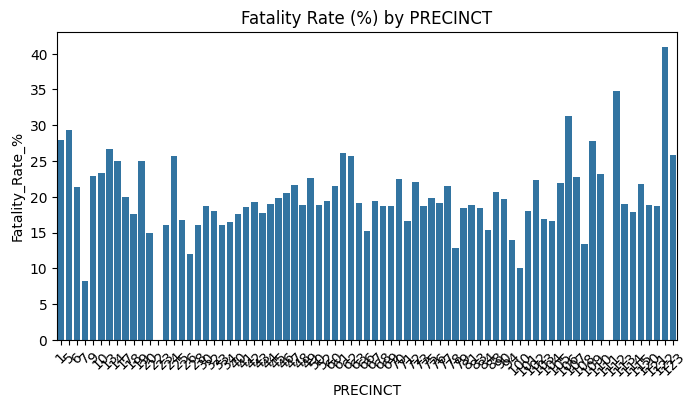

faltality summary table of JURISDICTION_CODE


,JURISDICTION_CODE,Total_Count,Fatal_Count,Fatality_Rate_%
1,1.0,74,15,20.270270
0,0.0,22809,4538,19.895655
2,2.0,4427,713,16.105715


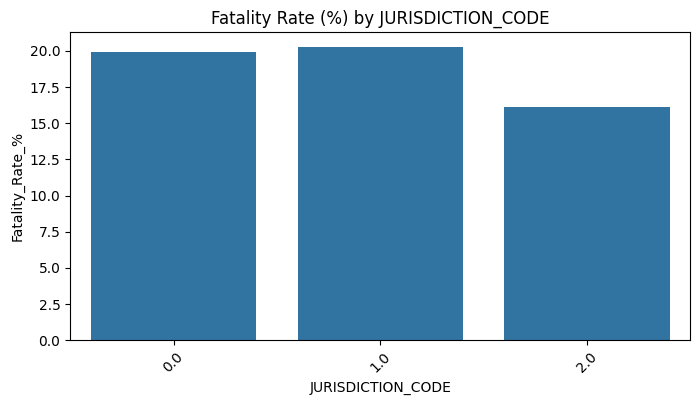

faltality summary table of LOCATION_DESC


,LOCATION_DESC,Total_Count,Fatal_Count,Fatality_Rate_%
7,CHECK CASH,1,1,100.000000
23,LOAN COMPANY,1,1,100.000000
30,SCHOOL,1,1,100.000000
39,VIDEO STORE,8,7,87.500000
37,TELECOMM. STORE,11,6,54.545455
10,DEPT STORE,9,4,44.444444
20,HOTEL/MOTEL,35,15,42.857143
12,DRUG STORE,14,6,42.857143
6,CHAIN STORE,5,2,40.000000
31,SHOE STORE,10,4,40.000000


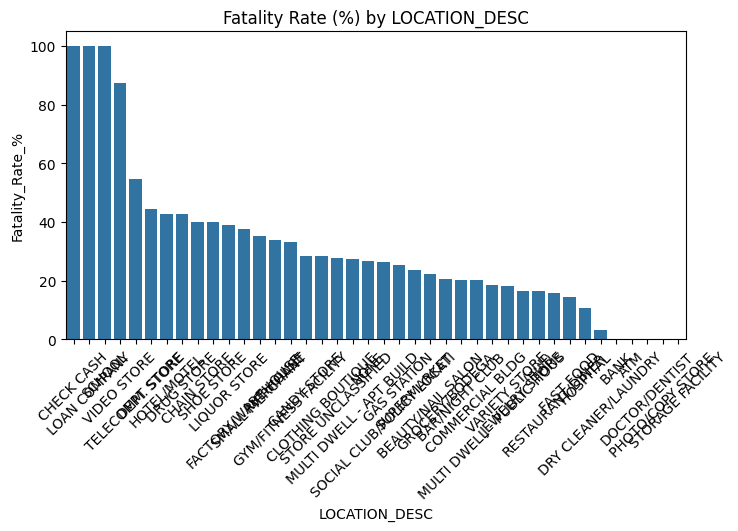

faltality summary table of PERP_AGE_GROUP


,PERP_AGE_GROUP,Total_Count,Fatal_Count,Fatality_Rate_%
6,65+,60,25,41.666667
5,45-64,617,218,35.332253
4,25-44,5687,1524,26.797960
2,18-24,6222,1302,20.925747
8,<18,1591,287,18.038969
0,(null),640,95,14.843750
9,UNKNOWN,3148,109,3.462516
1,1020,1,0,0.000000
3,224,1,0,0.000000
7,940,1,0,0.000000


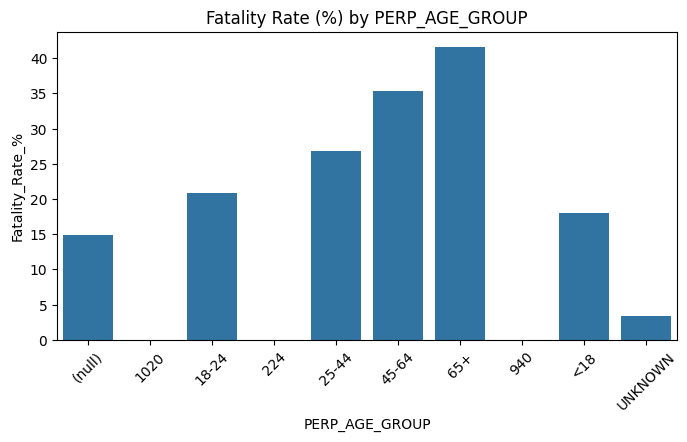

faltality summary table of PERP_SEX


,PERP_SEX,Total_Count,Fatal_Count,Fatality_Rate_%
1,F,424,112,26.415094
2,M,15439,3262,21.128311
0,(null),640,95,14.843750
3,U,1499,108,7.204803


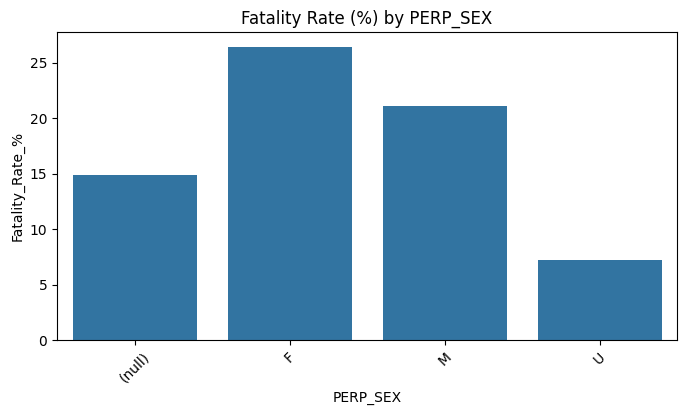

faltality summary table of PERP_RACE


,PERP_RACE,Total_Count,Fatal_Count,Fatality_Rate_%
6,WHITE,283,110,38.869258
2,ASIAN / PACIFIC ISLANDER,154,48,31.168831
7,WHITE HISPANIC,2341,565,24.134985
3,BLACK,11432,2379,20.810007
4,BLACK HISPANIC,1314,260,19.786910
0,(null),640,95,14.843750
5,UNKNOWN,1836,120,6.535948
1,AMERICAN INDIAN/ALASKAN NATIVE,2,0,0.000000


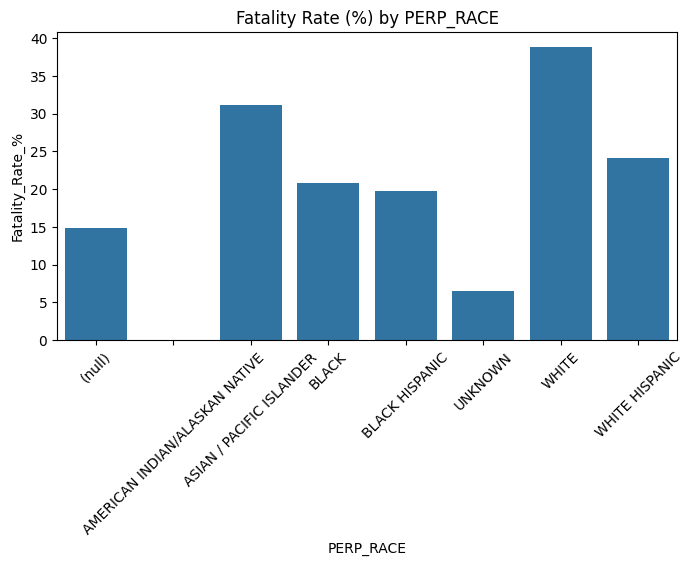

faltality summary table of VIC_AGE_GROUP


,VIC_AGE_GROUP,Total_Count,Fatal_Count,Fatality_Rate_%
4,65+,181,56,30.939227
3,45-64,1863,465,24.959742
6,UNKNOWN,61,15,24.590164
2,25-44,12281,2680,21.822327
1,18-24,10086,1680,16.656752
5,<18,2839,370,13.032758
0,1022,1,0,0.000000


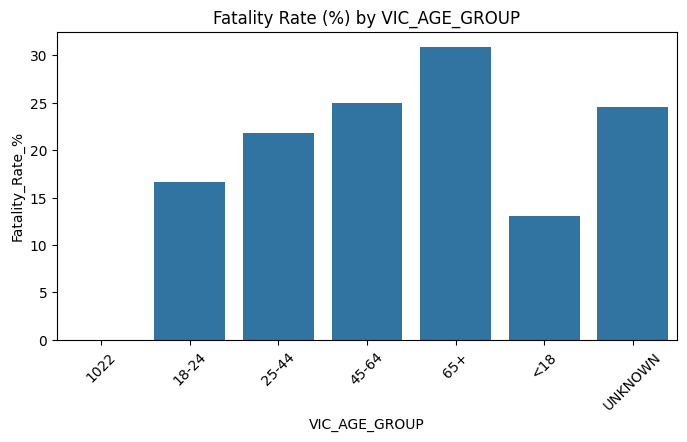

faltality summary table of VIC_SEX


,VIC_SEX,Total_Count,Fatal_Count,Fatality_Rate_%
0,F,2615,532,20.344168
1,M,24686,4733,19.172810
2,U,11,1,9.090909


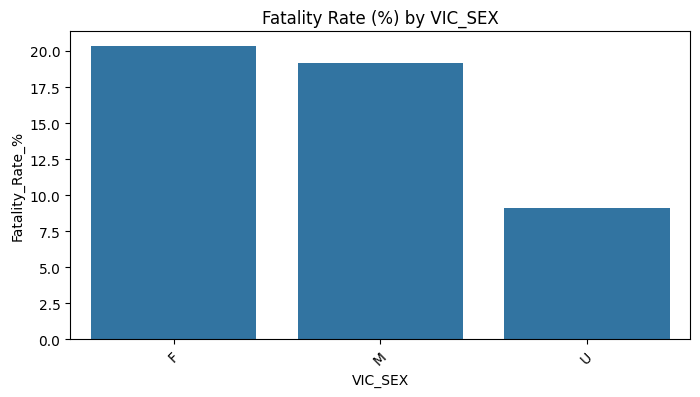

faltality summary table of VIC_RACE


,VIC_RACE,Total_Count,Fatal_Count,Fatality_Rate_%
5,WHITE,698,191,27.363897
1,ASIAN / PACIFIC ISLANDER,404,101,25.000000
6,WHITE HISPANIC,4049,853,21.066930
2,BLACK,19439,3682,18.941304
3,BLACK HISPANIC,2646,432,16.326531
4,UNKNOWN,66,7,10.606061
0,AMERICAN INDIAN/ALASKAN NATIVE,10,0,0.000000


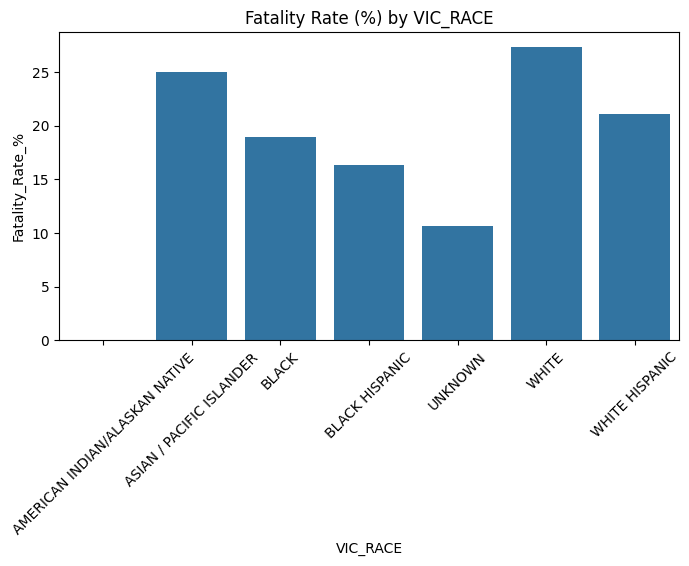

In [ ]:
cat_cols = df.select_dtypes(include=['object','category']).columns
cat_cols = [col for col in cat_cols if col not in ['MONTH_NAME','DAY_NAME']]

for col in cat_cols:
    print(f"faltality summary table of {col}")
    summary = fatality_summary(col)
    display(summary)

    plt.figure(figsize=(8,4))
    sns.barplot(x=col, y='Fatality_Rate_%', data=summary)

    plt.title(f"Fatality Rate (%) by {col}")
    plt.xticks(rotation=45)
    plt.show()

#Fatality Rate Analysis by Month and Day

To examine temporal patterns in fatal outcomes, fatality rate (%) is calculated for MONTH_NAME and DAY_NAME.

Categories are explicitly ordered to preserve natural chronological sequencing (January–December, Monday–Sunday), ensuring accurate trend visualization.

This analysis helps identify:

- Seasonal variation in fatal incidents

- Weekday vs weekend risk patterns

- Time-based trends in fatality rates

MONTH_NAME fatality summary table


,MONTH_NAME,Total_Count,Fatal_Count,Fatality_Rate_%
4,January,1716,340,19.813520
3,February,1340,280,20.895522
7,March,1688,327,19.372038
0,April,1983,395,19.919314
8,May,2571,506,19.681058
6,June,2829,501,17.709438
5,July,3238,575,17.757875
1,August,3156,542,17.173638
11,September,2572,522,20.295490
10,October,2279,453,19.877139


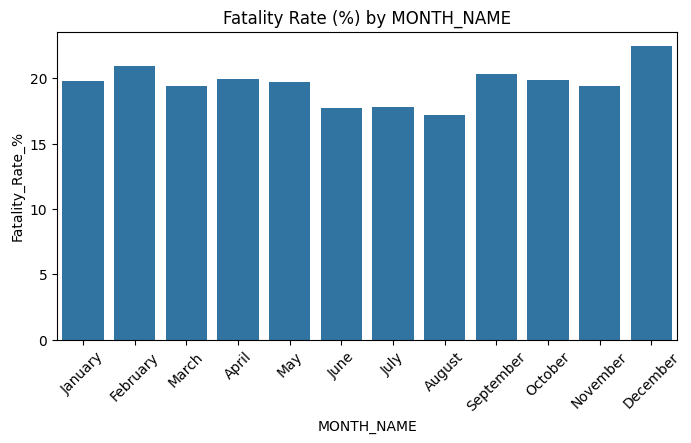

DAY_NAME fatality summary table


,DAY_NAME,Total_Count,Fatal_Count,Fatality_Rate_%
1,Monday,3883,760,19.572495
5,Tuesday,3163,591,18.684793
6,Wednesday,3000,628,20.933333
4,Thursday,3034,601,19.808833
0,Friday,3585,713,19.888424
2,Saturday,5195,941,18.113571
3,Sunday,5452,1032,18.928833


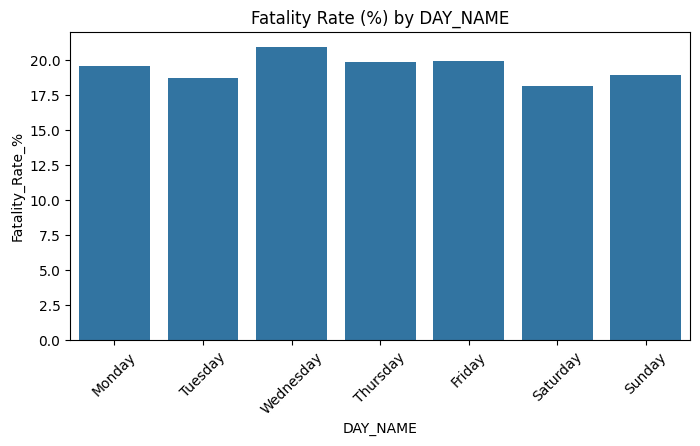

In [ ]:
ordered_categories = {
    'MONTH_NAME': [
        'January','February','March','April','May','June',
        'July','August','September','October','November','December'
    ],
    'DAY_NAME': [
        'Monday','Tuesday','Wednesday','Thursday',
        'Friday','Saturday','Sunday'
    ]
}

for col, order in ordered_categories.items():
    print(f"{col} fatality summary table")
    summary = fatality_summary(col)
    summary[col] = pd.Categorical(summary[col], categories=order, ordered=True)
    summary = summary.sort_values(col)

    display(summary)

    plt.figure(figsize=(8,4))
    sns.barplot(x=col, y='Fatality_Rate_%', data=summary)

    plt.title(f"Fatality Rate (%) by {col}")
    plt.xticks(rotation=45)
    plt.show()

#Chi-Square Test for Categorical Features

A Chi-Square test of independence is performed to evaluate the statistical association between each categorical feature and the target variable (STATISTICAL_MURDER_FLAG).

For each categorical column:

- A contingency table is created using pd.crosstab()

- The Chi-Square statistic and corresponding p-value are computed

- Results are summarized and sorted by p-value

**Interpretation**

- **p-value < 0.05** → Statistically significant relationship with fatality outcome

- **p-value ≥ 0.05** → Weak or no statistically significant association

This step helps identify categorical features that have meaningful predictive relevance for modeling.

In [ ]:
# Chi-Square Test
from scipy.stats import chi2_contingency

cat_cols = df.select_dtypes(include=['object','category']).columns
cat_cols = [col for col in cat_cols if col not in ['MONTH_NAME','DAY_NAME']]

chi_results = []

for col in cat_cols:

    contingency = pd.crosstab(df[col], df['STATISTICAL_MURDER_FLAG'])

    chi2, p, dof, expected = chi2_contingency(contingency)

    chi_results.append({
        'Feature': col,
        'Chi2 Statistic': chi2,
        'p-value': p
    })

chi_df = pd.DataFrame(chi_results)
chi_df = chi_df.sort_values(by='p-value')

display(chi_df)

,Feature,Chi2 Statistic,p-value
4,PERP_AGE_GROUP,834.619969,7.484914e-174
6,PERP_RACE,325.277765,2.398840e-66
7,VIC_AGE_GROUP,222.560987,2.958753e-45
5,PERP_SEX,187.935302,1.704530e-40
3,LOCATION_DESC,269.257468,3.477647e-36
9,VIC_RACE,67.951107,1.075124e-12
2,JURISDICTION_CODE,34.260964,3.633509e-08
1,PRECINCT,145.048791,3.168196e-06
0,BORO,8.364575,7.910010e-02
8,VIC_SEX,2.818779,2.442923e-01


#**Insights from bivariate categorical analayss**

**1️⃣ BORO – Fatality Rate**

- Staten Island shows highest fatality rate (~20.9%) despite low total incident volume.

- Manhattan shows comparatively lower fatality rate (~17.6%).

- Other boroughs remain close to overall average (~19–20%).

**Insight:**
- Incident volume ≠ fatality severity.
- BORO alone is not a strong differentiator (Chi-square p = 0.079 → not statistically significant at 5%).

** 2️⃣ PRECINCT**

- Fatality rate varies widely across precincts (0% to ~40%).

- Some precincts show extremely high fatality proportions.

- Chi-Square: p ≈ 3.16e-06 (Highly significant)

**Insight:**
Precinct-level location has statistically significant association with fatality outcome.

**3️⃣ JURISDICTION_CODE**

- Code 1 shows slightly higher fatality (~20.3%).

- Code 2 lower (~16.1%).

- Chi-Square: p ≈ 3.63e-08

**Insight:**
Jurisdiction type influences fatality likelihood.

**4️⃣ LOCATION_DESC**

- Certain commercial locations show high fatality proportions.

- Some categories show near-zero fatality (likely low sample size).

- Chi-Square: p ≈ 3.47e-36 (Very strong significance)

**Insight:**
Location type is a major contextual predictor of fatality.

** 5️⃣ PERP_AGE_GROUP**

Fatality rate increases with age:

- 18–24 → ~21%

- 45–64 → ~35%

- 65+ → ~41%

- Chi-Square: p ≈ 7.48e-174 (Extremely significant)

**Insight:**
Perpetrator age strongly influences fatality probability.

** 6️⃣ PERP_SEX**

- Female perpetrators show higher fatality rate (~26%) than males (~21%).

- Unknown category lowest.

- Chi-Square: p ≈ 1.70e-40

**Insight:**
Gender of perpetrator is statistically associated with fatal outcomes.

** 7️⃣ PERP_RACE**

- White perpetrators show highest fatality rate (~38%).

- Asian/Pacific Islander also high (~31%).

- Black perpetrators ~20%.

- Chi-Square: p ≈ 2.39e-66

**Insight:**
Perpetrator race has statistically significant association with fatality.

** 8️⃣ VIC_AGE_GROUP**

- Fatality rate increases with victim age.

- 65+ victims show highest fatality (~30%).

- Chi-Square: p ≈ 2.95e-45

**Insight:**
Victim age significantly influences survival probability.

**9️⃣ VIC_SEX**

- Female victims show slightly higher fatality (~20.3%) than males (~19.1%).

- Chi-Square: p ≈ 0.244

**Insight:**
Victim sex is NOT statistically significant predictor.

**🔟 VIC_RACE**

- White victims show highest fatality (~27%).

- Asian/Pacific Islander ~25%.

- Chi-Square: p ≈ 1.07e-12

**Insight:**
Victim race has significant statistical association with fatality.

** 1️⃣1️⃣ MONTH_NAME**

- December shows highest fatality (~22.4%).

- Summer months slightly lower (~17–18%).

(- Chi-square not shown but variation exists.)

**1️⃣2️⃣ DAY_NAME**

- Wednesday shows slightly higher fatality (~20.9%).

- Saturday slightly lower (~18%).

- Variation small across days.

**Big Strategic Conclusion**

Strong Predictors (Statistically Significant):

- PERP_AGE_GROUP
- PERP_RACE
-VIC_AGE_GROUP
- PERP_SEX
- LOCATION_DESC
- PRECINCT
- JURISDICTION_CODE
- VIC_RACE

**Modeling Implication**

- Demographic + contextual categorical features are primary drivers.

- Spatial coordinates alone are weak.

- Feature selection should prioritize statistically significant categorical variables.

In [ ]:
columns_to_drop = [
    'INCIDENT_KEY',
    'BORO',
    'VIC_SEX',
    'X_COORD_CD',
    'Y_COORD_CD',
    'MONTH_NAME',
    'DAY_NAME',
    'OCCUR_DATE',
    'OCCUR_TIME'
]

df = df.drop(columns=columns_to_drop)

In [ ]:
# SAFE MISSING VALUE HANDLING
cat_cols = df.select_dtypes(include=['object','category']).columns

for col in cat_cols:

    if df[col].dtype.name == 'category':
        # Add 'Unknown' as new category first
        df[col] = df[col].cat.add_categories('Unknown')

    df[col] = df[col].fillna('Unknown')


# Numerical columns
df['Latitude'] = df['Latitude'].fillna(df['Latitude'].median())
df['Longitude'] = df['Longitude'].fillna(df['Longitude'].median())

print("Remaining Missing Values:")
print(df.isnull().sum())

Remaining Missing Values:
PRECINCT                   0
JURISDICTION_CODE          0
LOCATION_DESC              0
STATISTICAL_MURDER_FLAG    0
PERP_AGE_GROUP             0
PERP_SEX                   0
PERP_RACE                  0
VIC_AGE_GROUP              0
VIC_RACE                   0
Latitude                   0
Longitude                  0
YEAR                       0
MONTH                      0
DAY_OF_WEEK                0
HOUR                       0
dtype: int64


In [ ]:
# REMOVE INVALID AGE CATEGORIES

# Invalid values list
invalid_perp_age = ['1020', '224', '940']
invalid_vic_age = ['1022']

# Remove invalid perpetrator age rows
df = df[~df['PERP_AGE_GROUP'].isin(invalid_perp_age)]

# Remove invalid victim age rows
df = df[~df['VIC_AGE_GROUP'].isin(invalid_vic_age)]

# Reset index after filtering
df = df.reset_index(drop=True)

print("Remaining shape after removing invalid categories:", df.shape)

Remaining shape after removing invalid categories: (27308, 15)


In [ ]:
df.to_csv("cleaned_shooting_data.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
